# Preliminary Results — First Region per Country

Gathers all `results.json` files from the first region of every country and visualises
how the once-in-100-year discharge event shifts across climate scenarios.

In [1]:
import json
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from rich import print

## 1. Gather results

In [2]:

REQUIRED_TOP_LEVEL = {'caravan_id', 'catchment_area_km2', 'calibration', 'return_periods', 'koppen_geiger'}
REQUIRED_CALIBRATION = {'KGE', 'NSE', 'period'}
REQUIRED_RP_KEYS = {
    'observed_reference',
    'modelled historic discharge, forcing: CMIP6,MPI-ESM1-2-LR,r1i1p1f1',
    'ERA5',
    'DestinE_historical',
    'ssp126', 'ssp245', 'ssp370', 'ssp585',
    'DestinE_future',
}
REQUIRED_OBS_REF = {'q100_mm_d', 'q1000_mm_d'}
REQUIRED_RP_SUBKEYS = {'rp_at_obs_q100', 'rp_at_obs_q1000'}
REQUIRED_KG = {
    'Af','Am','Aw','BWh','BWk','BSh','BSk',
    'Csa','Csb','Csc','Cwa','Cwb','Cwc','Cfa','Cfb','Cfc',
    'Dsa','Dsb','Dsc','Dsd','Dwa','Dwb','Dwc','Dwd','Dfa','Dfb','Dfc','Dfd',
    'ET','EF',
}


def validate(data):
    """Return list of missing-field problems; empty list means complete."""
    problems = []

    missing_top = REQUIRED_TOP_LEVEL - data.keys()
    if missing_top:
        problems.append(f"missing top-level: {sorted(missing_top)}")
        # Can't keep validating sub-structures that aren't there
        if not {'calibration', 'return_periods', 'koppen_geiger'} <= data.keys():
            return problems

    cal = data.get('calibration', {})
    missing_cal = REQUIRED_CALIBRATION - cal.keys()
    if missing_cal:
        problems.append(f"calibration missing: {sorted(missing_cal)}")

    rp = data.get('return_periods', {})
    missing_rp = REQUIRED_RP_KEYS - rp.keys()
    if missing_rp:
        problems.append(f"return_periods missing: {sorted(missing_rp)}")

    obs = rp.get('observed_reference', {})
    missing_obs = REQUIRED_OBS_REF - obs.keys() if isinstance(obs, dict) else REQUIRED_OBS_REF
    if missing_obs:
        problems.append(f"observed_reference missing: {sorted(missing_obs)}")

    for key in REQUIRED_RP_KEYS - {'observed_reference'}:
        sub = rp.get(key)
        if not isinstance(sub, dict):
            continue  # already flagged above if missing
        missing_sub = REQUIRED_RP_SUBKEYS - sub.keys()
        if missing_sub:
            problems.append(f"return_periods[{key!r}] missing: {sorted(missing_sub)}")

    kg = data.get('koppen_geiger', {})
    if isinstance(kg, dict):
        missing_kg = REQUIRED_KG - kg.keys()
        if missing_kg:
            problems.append(f"koppen_geiger missing: {sorted(missing_kg)}")

    return problems


base_path = Path('regions')
all_results = []
incomplete = []

for country_dir in sorted(base_path.iterdir()):
    if not country_dir.is_dir():
        continue
    country = country_dir.name
    region_dirs = sorted(d for d in country_dir.iterdir() if d.is_dir())
    if not region_dirs:
        continue
    first_region = region_dirs[0]
    results_file = first_region / 'results.json'

    if not results_file.exists():
        print(f'[yellow]–[/yellow] {country:30s} → {first_region.name}  [dim](no results yet)[/dim]')
        continue

    with open(results_file) as f:
        data = json.load(f)

    problems = validate(data)
    if problems:
        incomplete.append((country, first_region.name, problems))
        print(f'[red]✗[/red] {country:30s} → {first_region.name}  [dim]({len(problems)} issue(s))[/dim]')
        for p in problems:
            print(f'      [dim]· {p}[/dim]')
    else:
        data['country'] = country
        all_results.append(data)
        print(f'[green]✓[/green] {country:30s} → {first_region.name}')

print(f'\n[bold]{len(all_results)} region(s) complete.[/bold]')
if incomplete:
    print(f'[bold red]{len(incomplete)} region(s) incomplete.[/bold red]')

✓ australia                      → camelsaus_102101A

✗ austria                        → lamah_200048  (1 issue(s))

· missing top-level: ['calibration']

✓ brazil                         → camelsbr_17345000

✗ canada                         → hysets_01AD003  (1 issue(s))

...

✓ switzerland                    → lamah_185

✓ united_states_of_america       → camels_01022500

✓ wales                          → camelsgb_54028

9 region(s) complete.

5 region(s) incomplete.

## 2. Parse return-period data

In [3]:
def parse_rp(value):
    """Return (mean, std) for a return-period value.
    
    Values can be a plain number or a 'mean ± std' string.
    """
    if isinstance(value, (int, float)):
        return float(value), 0.0
    s = str(value)
    if '\u00b1' in s:          # ±
        parts = s.split('\u00b1')
        return float(parts[0].strip()), float(parts[1].strip())
    return float(s.strip()), 0.0


def get_scenario_label(key):
    """Map a results.json key to a short display label and display order."""
    k = key.lower()
    if key == 'observed_reference':
        return 'Observed (ref)', 0
    if 'modelled discharge' in k or ('cmip' in k and 'ssp' not in k):
        return 'CMIP6 hist', 1
    if k == 'era5':
        return 'ERA5', 2
    if 'destine' in k and ('hist' in k or 'historical' in k):
        return 'DestinE hist', 3
    if 'ssp126' in k:
        return 'SSP1-2.6', 4
    if 'ssp245' in k:
        return 'SSP2-4.5', 5
    if 'ssp370' in k:
        return 'SSP3-7.0', 6
    if 'ssp585' in k:
        return 'SSP5-8.5', 7
    if 'destine' in k:
        return 'DestinE future', 8
    return key, 99


SCENARIO_COLORS = {
    'Observed (ref)':  '#000000',
    'CMIP6 hist':      '#4393c3',
    'ERA5':             '#1f77b4',
    'DestinE hist':    '#00BCD4',
    'SSP1-2.6':         '#2ca02c',
    'SSP2-4.5':         '#bcbd22',
    'SSP3-7.0':         '#ff7f0e',
    'SSP5-8.5':         '#d62728',
    'DestinE future':  '#9467bd',
}


# Build a tidy DataFrame: one row per (region × scenario)
rows = []
for r in all_results:
    rp_data = r.get('return_periods', {})
    for key, vals in rp_data.items():
        if key == 'observed_reference':
            # The reference point is always 100 years by definition
            rows.append({
                'country':    r['country'],
                'caravan_id': r['caravan_id'],
                'scenario_key':   key,
                'scenario_label': 'Observed (ref)',
                'order':          0,
                'rp_mean':        100.0,
                'rp_std':         0.0,
            })
            continue
        rp_val = vals.get('rp_at_obs_q100')
        if rp_val is None:
            continue
        mean, std = parse_rp(rp_val)
        label, order = get_scenario_label(key)
        rows.append({
            'country':        r['country'],
            'caravan_id':     r['caravan_id'],
            'scenario_key':   key,
            'scenario_label': label,
            'order':          order,
            'rp_mean':        mean,
            'rp_std':         std,
        })

df = pd.DataFrame(rows).sort_values(['country', 'order']).reset_index(drop=True)
print(df[['country', 'caravan_id', 'scenario_label', 'rp_mean', 'rp_std']])

country         caravan_id  scenario_label  rp_mean  rp_std
0   australia  camelsaus_102101A  Observed (ref)   100.00    0.00
1   australia  camelsaus_102101A      CMIP6 hist     6.36    0.00
2   australia  camelsaus_102101A            ERA5     6.82    0.00
3   australia  camelsaus_102101A    DestinE hist    10.59    0.00
4   australia  camelsaus_102101A        SSP1-2.6     5.21    0.73
..        ...                ...             ...      ...     ...
76      wales     camelsgb_54028        SSP1-2.6     3.96    0.20
77      wales     camelsgb_54028        SSP2-4.5     4.61    0.68
78      wales     camelsgb_54028        SSP3-7.0     4.07    1.49
79      wales     camelsgb_54028        SSP5-8.5     4.03    0.25
80      wales     camelsgb_54028  DestinE future     5.61    0.00

[81 rows x 5 columns]

## 3. Plot — shift of the once-in-100-year discharge

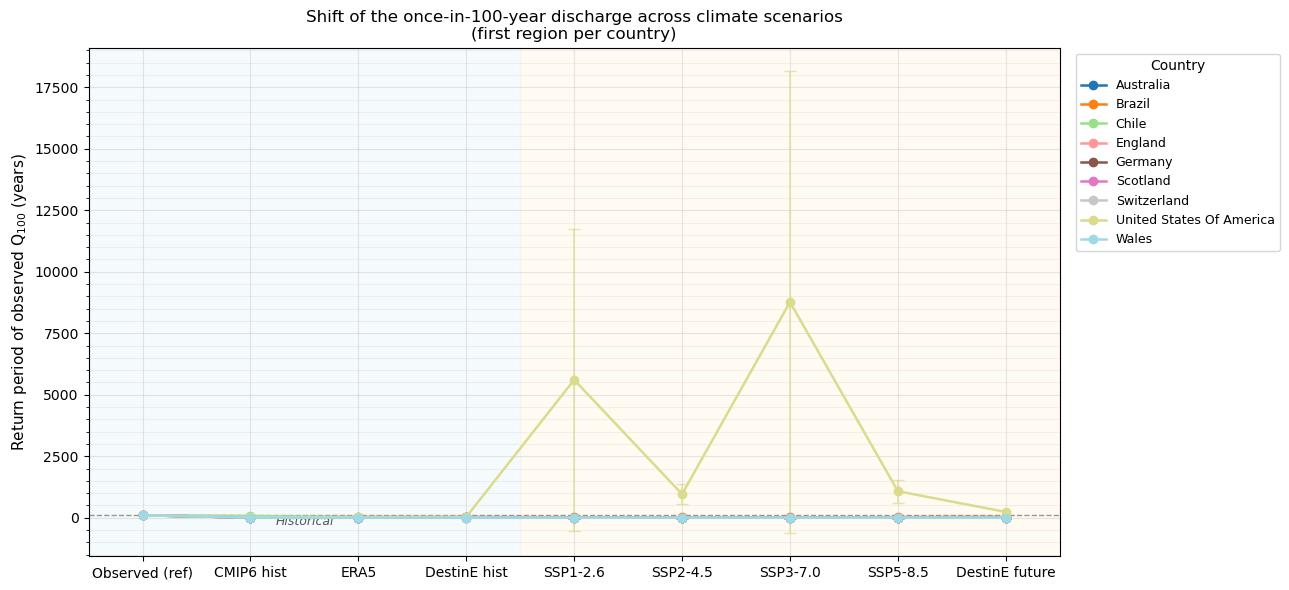

In [4]:
# Ordered scenario labels for the x-axis
ordered_labels = [
    'Observed (ref)',
    'CMIP6 hist',
    'ERA5',
    'DestinE hist',
    'SSP1-2.6',
    'SSP2-4.5',
    'SSP3-7.0',
    'SSP5-8.5',
    'DestinE future',
]
label_to_x = {lbl: i for i, lbl in enumerate(ordered_labels)}

# One colour per country so lines are distinguishable
countries = df['country'].unique()
country_cmap = plt.cm.get_cmap('tab20', len(countries))
country_color = {c: country_cmap(i) for i, c in enumerate(countries)}

fig, ax = plt.subplots(figsize=(13, 6))

# Reference line
ax.axhline(100, color='black', linestyle='--', linewidth=1, alpha=0.4, zorder=1)

# Shaded background: left = historical, right = future
ax.axvspan(-0.5, 3.5, color='#e8f4f8', alpha=0.4, zorder=0)
ax.axvspan(3.5, len(ordered_labels) - 0.5, color='#fff3e0', alpha=0.4, zorder=0)
ax.text(1.5, ax.get_ylim()[1] if ax.get_ylim()[1] != 1.0 else 200,
        'Historical', ha='center', va='top', color='#555', fontsize=9, style='italic')

# Plot per country
for country, group in df.groupby('country'):
    color = country_color[country]
    x_vals, y_vals, y_errs = [], [], []
    for _, row in group.iterrows():
        lbl = row['scenario_label']
        if lbl in label_to_x:
            x_vals.append(label_to_x[lbl])
            y_vals.append(row['rp_mean'])
            y_errs.append(row['rp_std'])

    ax.plot(x_vals, y_vals, 'o-', color=color, linewidth=1.8,
            markersize=6, label=country.replace('_', ' ').title(), zorder=3)

    for x, y, ye in zip(x_vals, y_vals, y_errs):
        if ye > 0:
            ax.errorbar(x, y, yerr=ye, fmt='none', ecolor=color,
                        elinewidth=1.2, capsize=4, alpha=0.7, zorder=2)

ax.set_xticks(range(len(ordered_labels)))
ax.set_xticklabels(ordered_labels, fontsize=10)
ax.set_ylabel('Return period of observed Q$_{100}$ (years)', fontsize=11)
ax.set_title(
    'Shift of the once-in-100-year discharge across climate scenarios\n'
    '(first region per country)',
    fontsize=12,
)
ax.set_xlim(-0.5, len(ordered_labels) - 0.5)
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which='major', alpha=0.3)
ax.grid(True, which='minor', alpha=0.15)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9,
          framealpha=0.8, title='Country')

plt.tight_layout()
# plt.savefig('preliminary_q100_shift.png', dpi=150, bbox_inches='tight')
plt.show()
# print('Saved: preliminary_q100_shift.png')

## 4. Summary table

In [5]:
pivot = df.pivot_table(
    index='country',
    columns='scenario_label',
    values='rp_mean',
    aggfunc='first',
)

# Reorder columns
present_cols = [c for c in ordered_labels if c in pivot.columns]
pivot = pivot[present_cols]
pivot.index = pivot.index.str.replace('_', ' ').str.title()

pivot.style \
    .format('{:.1f}') \
    .background_gradient(cmap='RdYlGn_r', axis=None, vmin=50, vmax=200) \
    .set_caption(
        'Return period (years) of the historically-observed 100-year discharge'
        ' — values > 100 indicate that the event becomes rarer; < 100 means more frequent'
    )

scenario_label,Observed (ref),CMIP6 hist,ERA5,DestinE hist,SSP1-2.6,SSP2-4.5,SSP3-7.0,SSP5-8.5,DestinE future
country,,,,,,,,,
Australia,100.0,6.4,6.8,10.6,5.2,5.2,4.7,4.6,3.9
Brazil,100.0,17.3,31.3,29.2,19.1,16.3,14.2,20.4,33.0
Chile,100.0,69.5,15.3,17.0,4.2,5.5,4.4,4.2,3.6
England,100.0,1.7,2.4,1.8,2.3,2.6,2.5,2.2,4.4
Germany,100.0,5.7,5.8,9.2,4.8,4.1,4.7,4.5,4.5
Scotland,100.0,2.5,4.5,4.5,4.2,5.6,3.5,5.0,6.5
Switzerland,100.0,5.4,18.0,13.3,2.0,2.0,2.0,2.1,2.3
United States Of America,100.0,23.1,26.6,30.8,5606.3,957.4,8768.8,1077.9,233.5
Wales,100.0,5.8,6.2,5.5,4.0,4.6,4.1,4.0,5.6
